In [1]:
import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# GLOBAL CONFIG (single source of truth)
# -----------------------------
FIELDS_DIR = "sdss_data/fields"
PATTERN = os.path.join(FIELDS_DIR, "sdss_*.csv")

TARGET_PATH = os.path.join(FIELDS_DIR, "sdss_target.csv")

# quality cuts
ERR_MAX = 0.15
G0_MAX = 23.5
R0_MAX = 23.5

# Sagittarius reference distance
d_pc = 33_400.0
DM_SGR = 5.0 * np.log10(d_pc / 10.0)  # ~17.62

# candidate selection thresholds
CHI2_THRESH = 6.18     # ~95% for 2 dof (tunable)
DM_TOL = 0.35          # mag (tunable)
DG_WINDOW = 0.50       # mag window for iso-point prefilter
NBINS = 200            # speed/accuracy tradeoff

# reproducibility
random.seed(0)

In [2]:
# Read in Dartmouth isochrone files
from isochrones.dartmouth_iso import load_isochrones
isos = load_isochrones("isochrones")
iso5 = isos["5gyr"]
iso13 = isos["13gyr"]

In [3]:
# Read in SDSS data
df = pd.read_csv(TARGET_PATH, comment="#")

# dereddened apparent mags
df["g0"] = df["psfMag_g"] - df["extinction_g"]
df["r0"] = df["psfMag_r"] - df["extinction_r"]
df["g_r"] = df["g0"] - df["r0"]

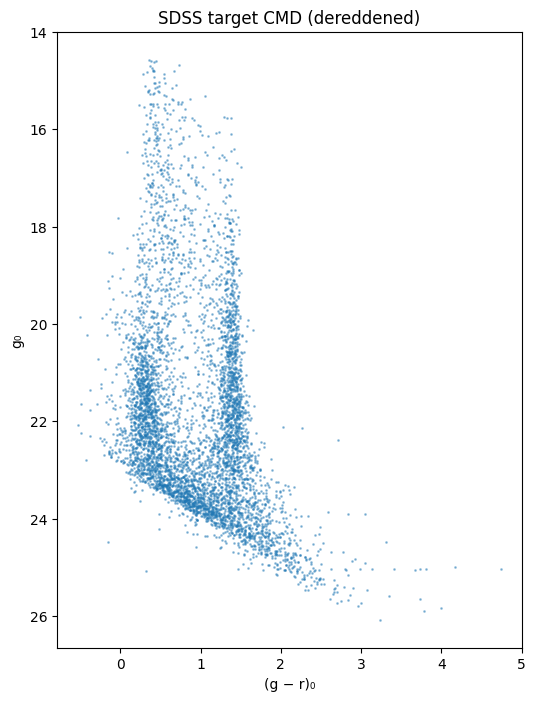

In [4]:
# Plot CMD as sanity check
plt.figure(figsize=(6,8))
plt.scatter(df["g_r"], df["g0"], s=1, alpha=0.4)
plt.gca().invert_yaxis()
plt.xlabel("(g − r)₀")
plt.ylabel("g₀")
plt.title("SDSS target CMD (dereddened)")
plt.show()

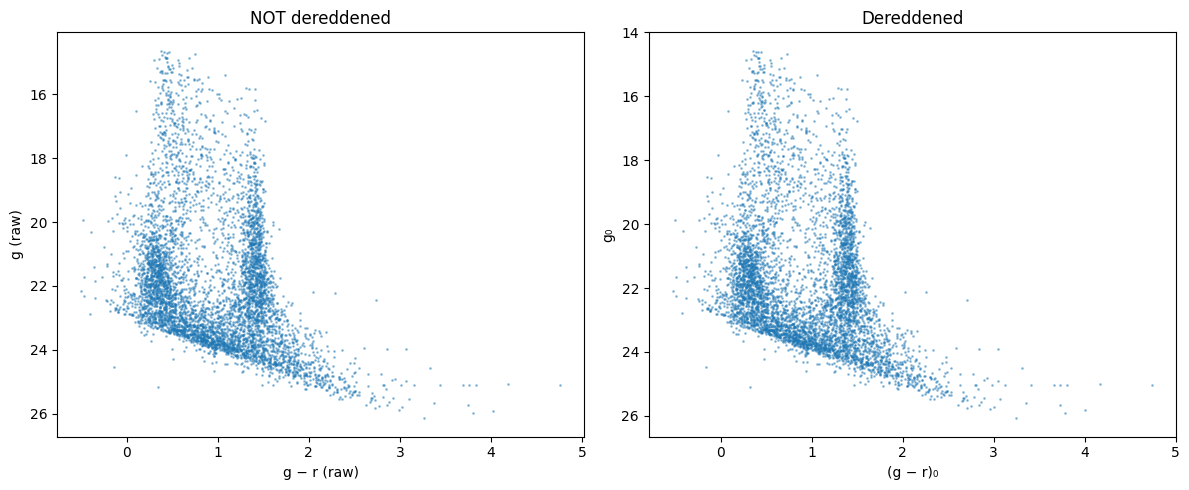

In [5]:
# Plot dereddened vs reddened CMD side by side
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(df["psfMag_g"]-df["psfMag_r"], df["psfMag_g"], s=1, alpha=0.4)
plt.gca().invert_yaxis()
plt.xlabel("g − r (raw)")
plt.ylabel("g (raw)")
plt.title("NOT dereddened")

plt.subplot(1,2,2)
plt.scatter(df["g_r"], df["g0"], s=1, alpha=0.4)
plt.gca().invert_yaxis()
plt.xlabel("(g − r)₀")
plt.ylabel("g₀")
plt.title("Dereddened")

plt.tight_layout()
plt.show()

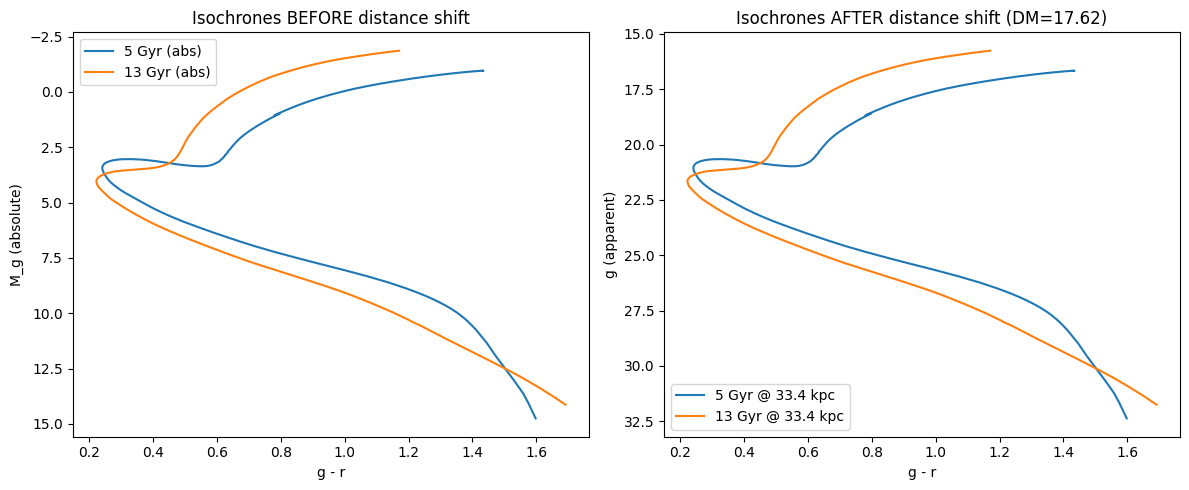

Distance modulus used: DM = 17.6187 mag for d = 33.4 kpc


In [6]:

# --- Distance modulus for d = 33.4 kpc ---
d_pc = 33_400.0
DM = DM_SGR

def iso_before_after(iso, DM):
    """Return (color_abs, Mg_abs, color_app, g_app) for one isochrone."""
    df_iso = iso.df.copy()

    # BEFORE: absolute magnitudes (intrinsic)
    color_abs = df_iso["sdss_g"] - df_iso["sdss_r"]
    Mg_abs = df_iso["sdss_g"]

    # AFTER: shifted to apparent magnitudes at the Sgr distance
    g_app = df_iso["sdss_g"] + DM
    r_app = df_iso["sdss_r"] + DM
    color_app = g_app - r_app

    return color_abs, Mg_abs, color_app, g_app


c5_abs, g5_abs, c5_app, g5_app = iso_before_after(iso5, DM)
c13_abs, g13_abs, c13_app, g13_app = iso_before_after(iso13, DM)

# --- Plot BEFORE/AFTER for distance correction ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# BEFORE (absolute mags)
ax[0].plot(c5_abs, g5_abs, lw=1.5, label="5 Gyr (abs)")
ax[0].plot(c13_abs, g13_abs, lw=1.5, label="13 Gyr (abs)")
ax[0].invert_yaxis()
ax[0].set_xlabel("g - r")
ax[0].set_ylabel("M_g (absolute)")
ax[0].set_title("Isochrones BEFORE distance shift")
ax[0].legend()

# AFTER (apparent mags at 33.4 kpc)
ax[1].plot(c5_app, g5_app, lw=1.5, label="5 Gyr @ 33.4 kpc")
ax[1].plot(c13_app, g13_app, lw=1.5, label="13 Gyr @ 33.4 kpc")
ax[1].invert_yaxis()
ax[1].set_xlabel("g - r")
ax[1].set_ylabel("g (apparent)")
ax[1].set_title(f"Isochrones AFTER distance shift (DM={DM:.2f})")
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Distance modulus used: DM = {DM:.4f} mag for d = {d_pc/1000:.1f} kpc")

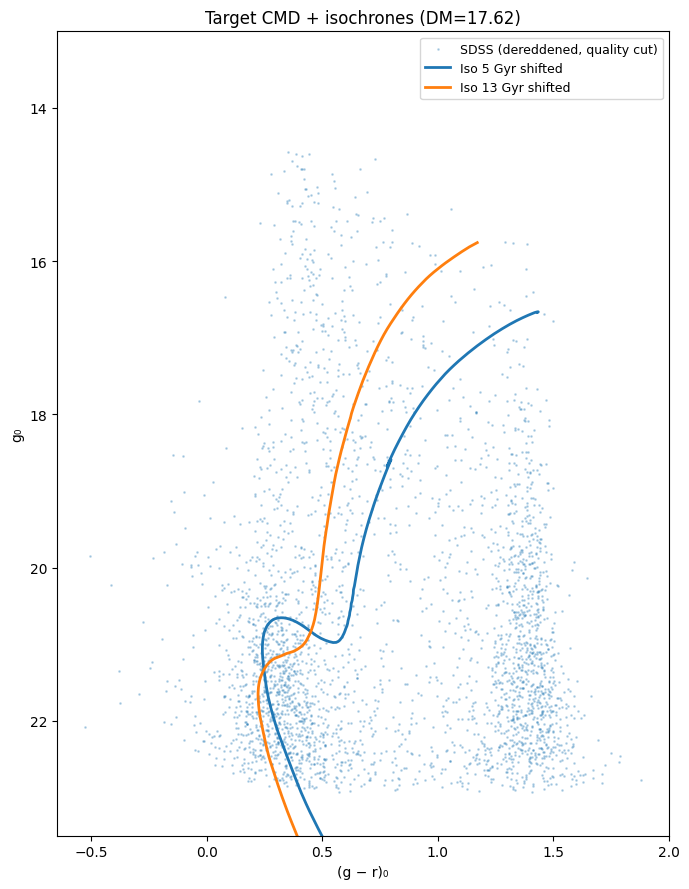

Overlay used DM = 17.6187; SDSS points = 3206 / 5448


In [7]:
DM = DM_SGR

mask = (
    (df["psfMagErr_g"] < ERR_MAX) &
    (df["psfMagErr_r"] < ERR_MAX) &
    (df["g0"] < G0_MAX) &
    (df["r0"] < R0_MAX)
)
d = df[mask].copy()

def shifted_iso(iso, DM):
    iso_df = iso.df
    g_app = iso_df["sdss_g"] + DM
    r_app = iso_df["sdss_r"] + DM
    c_app = g_app - r_app
    return c_app.to_numpy(), g_app.to_numpy()

c5, g5 = shifted_iso(iso5, DM)
c13, g13 = shifted_iso(iso13, DM)

plt.figure(figsize=(7, 9))
plt.scatter(d["g_r"], d["g0"], s=1, alpha=0.25, label="SDSS (dereddened, quality cut)")
plt.plot(c5, g5, lw=2, label="Iso 5 Gyr shifted")
plt.plot(c13, g13, lw=2, label="Iso 13 Gyr shifted")
plt.gca().invert_yaxis()
plt.xlabel("(g − r)₀")
plt.ylabel("g₀")
plt.title(f"Target CMD + isochrones (DM={DM:.2f})")
plt.ylim(23.5, 13)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Overlay used DM = {DM:.4f}; SDSS points = {len(d)} / {len(df)}")

In [10]:
# -----------------------------
# Isochrone arrays (ABSOLUTE mags!)
# -----------------------------
def iso_abs_arrays(iso):
    df_iso = iso.df
    Mg = df_iso["sdss_g"].to_numpy()
    Mr = df_iso["sdss_r"].to_numpy()
    return Mg, Mr

Mg5, Mr5 = iso_abs_arrays(iso5)
Mg13, Mr13 = iso_abs_arrays(iso13)

def load_field_csv(path):
    df0 = pd.read_csv(path, comment="#")

    df0["g0"] = df0["psfMag_g"] - df0["extinction_g"]
    df0["r0"] = df0["psfMag_r"] - df0["extinction_r"]
    df0["g_r"] = df0["g0"] - df0["r0"]

    df0["sig_g"] = df0["psfMagErr_g"]
    df0["sig_r"] = df0["psfMagErr_r"]
    df0["sig_gr"] = np.sqrt(df0["sig_g"]**2 + df0["sig_r"]**2)

    m = (
        (df0["sig_g"] < ERR_MAX) &
        (df0["sig_r"] < ERR_MAX) &
        (df0["g0"] < G0_MAX) &
        (df0["r0"] < R0_MAX)
    )
    return df0[m].copy()

def min_chi2_dm_to_iso(star_g0, star_r0, sig_g, sig_r, Mg_iso, Mr_iso, dg_window=0.5, nbins=200):
    """
    For each star, compute min chi^2 distance to isochrone allowing DM to vary.
    For each isochrone point i, analytic best DM is:
        DM_i = (w_g*(g0-Mg_i) + w_r*(r0-Mr_i)) / (w_g + w_r)
    Then chi^2_i = (dg/sig_g)^2 + (dr/sig_r)^2 at that DM_i.
    We take the minimum chi^2_i over nearby isochrone points (prefiltered by Mg).
    """
    gmin, gmax = np.nanmin(Mg_iso), np.nanmax(Mg_iso)
    edges = np.linspace(gmin, gmax, nbins + 1)
    bin_id = np.clip(np.digitize(Mg_iso, edges) - 1, 0, nbins - 1)

    bins = [[] for _ in range(nbins)]
    for i, b in enumerate(bin_id):
        bins[b].append(i)

    approx_Mg = star_g0 - DM_SGR
    star_bin = np.clip(np.digitize(approx_Mg, edges) - 1, 0, nbins - 1)

    dg_per_bin = (gmax - gmin) / nbins
    half_bins = max(1, int(np.ceil(dg_window / dg_per_bin)))

    DM_best = np.full_like(star_g0, np.nan, dtype=float)
    chi2_min = np.full_like(star_g0, np.inf, dtype=float)

    w_g = 1.0 / (sig_g**2)
    w_r = 1.0 / (sig_r**2)
    wsum = w_g + w_r

    for j in range(len(star_g0)):
        b0 = max(0, star_bin[j] - half_bins)
        b1 = min(nbins - 1, star_bin[j] + half_bins)

        cand = []
        for b in range(b0, b1 + 1):
            cand.extend(bins[b])
        if not cand:
            continue

        Mg = Mg_iso[cand]
        Mr = Mr_iso[cand]

        keep = np.abs(Mg - approx_Mg[j]) <= dg_window
        if not np.any(keep):
            continue

        Mg = Mg[keep]
        Mr = Mr[keep]

        DM_i = (w_g[j]*(star_g0[j] - Mg) + w_r[j]*(star_r0[j] - Mr)) / wsum[j]

        dg = star_g0[j] - (Mg + DM_i)
        dr = star_r0[j] - (Mr + DM_i)
        chi2 = (dg/sig_g[j])**2 + (dr/sig_r[j])**2

        k = np.argmin(chi2)
        chi2_min[j] = chi2[k]
        DM_best[j] = DM_i[k]

    return chi2_min, DM_best

def define_msto_box():
    # conservative “MSTO-ish” box for Sgr at DM_SGR; tune if needed
    return dict(gmin=20.0, gmax=22.5, cmin=0.15, cmax=0.65)

msto = define_msto_box()

In [11]:
paths = sorted([p for p in glob.glob(PATTERN) if "FAILED_" not in os.path.basename(p)])
if not paths:
    raise FileNotFoundError(f"No files matched {PATTERN}")

fields = []
for p in paths:
    fid = os.path.basename(p).replace("sdss_", "").replace(".csv", "")
    dfp = load_field_csv(p)

    # best-fit DM + chi2 for each isochrone
    chi2_5,  DM5  = min_chi2_dm_to_iso(dfp["g0"].to_numpy(), dfp["r0"].to_numpy(),
                                      np.maximum(dfp["sig_g"].to_numpy(), 1e-6),
                                      np.maximum(dfp["sig_r"].to_numpy(), 1e-6),
                                      Mg5, Mr5, dg_window=DG_WINDOW, nbins=NBINS)

    chi2_13, DM13 = min_chi2_dm_to_iso(dfp["g0"].to_numpy(), dfp["r0"].to_numpy(),
                                      np.maximum(dfp["sig_g"].to_numpy(), 1e-6),
                                      np.maximum(dfp["sig_r"].to_numpy(), 1e-6),
                                      Mg13, Mr13, dg_window=DG_WINDOW, nbins=NBINS)

    dfp["chi2_5"] = chi2_5
    dfp["chi2_13"] = chi2_13
    dfp["DM5_best"] = DM5
    dfp["DM13_best"] = DM13

    # candidate = good chi2 AND DM near Sgr
    cand5  = np.isfinite(chi2_5)  & (chi2_5 < CHI2_THRESH)  & np.isfinite(DM5)  & (np.abs(DM5  - DM_SGR) < DM_TOL)
    cand13 = np.isfinite(chi2_13) & (chi2_13 < CHI2_THRESH) & np.isfinite(DM13) & (np.abs(DM13 - DM_SGR) < DM_TOL)

    dfp["cand_5"] = cand5
    dfp["cand_13"] = cand13
    dfp["cand_both"] = cand5 & cand13
    dfp["cand_5only"] = cand5 & ~cand13
    dfp["cand_13only"] = cand13 & ~cand5
    dfp["cand_either"] = cand5 | cand13

    # MSTO mask + MSTO candidates
    dfp["in_msto"] = (
        (dfp["g0"] >= msto["gmin"]) & (dfp["g0"] <= msto["gmax"]) &
        (dfp["g_r"] >= msto["cmin"]) & (dfp["g_r"] <= msto["cmax"])
    )
    dfp["cand_msto"] = dfp["cand_either"] & dfp["in_msto"]

    fields.append((fid, dfp))

fields = sorted(fields, key=lambda t: (t[0] != "target", t[0]))
print(f"Loaded {len(fields)} fields from {FIELDS_DIR}")
print(f"Using DM_SGR={DM_SGR:.2f}, DM_TOL={DM_TOL}, CHI2<{CHI2_THRESH}, MSTO={msto}")

Loaded 31 fields from sdss_data/fields
Using DM_SGR=17.62, DM_TOL=0.35, CHI2<6.18, MSTO={'gmin': 20.0, 'gmax': 22.5, 'cmin': 0.15, 'cmax': 0.65}


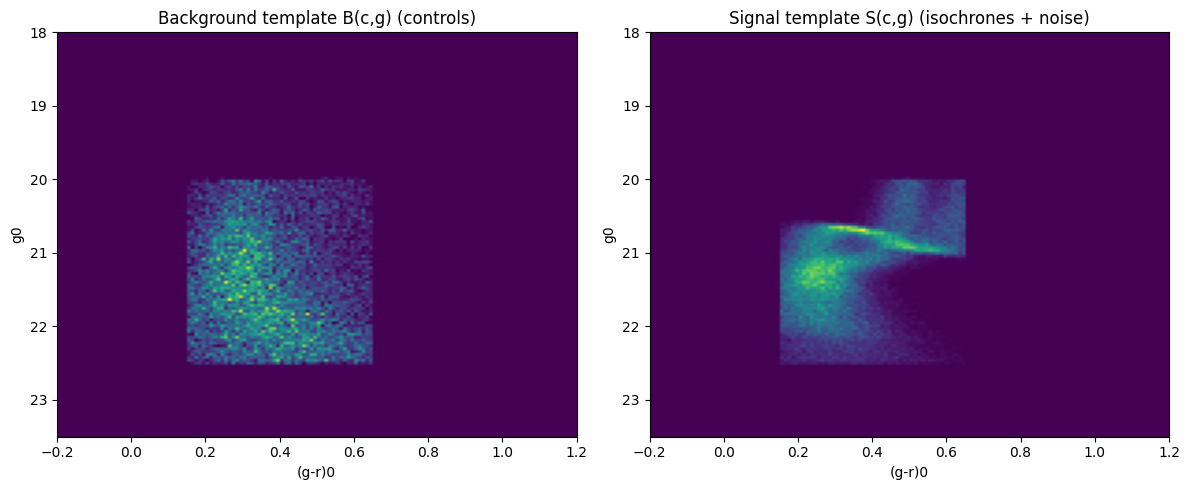

In [ ]:
# -----------------------------
# Matched filter configuration
# -----------------------------
# CMD binning (tune if needed)
C_MIN, C_MAX = -0.2, 1.2
G_MIN, G_MAX = 18.0, 23.5
NBIN_C, NBIN_G = 140, 140

# small floor to avoid division blow-ups
EPS = 1e-6

# How many synthetic "signal" points to generate
NSIM = 300_000

# Use both isochrones in the signal mixture (weights can be tuned)
W5, W13 = 0.5, 0.5   # start equal

# Optional: restrict filter to MSTO-ish region only (recommended)
USE_MSTO_ONLY = True

# -----------------------------
# Convenience: extract target/controls
# -----------------------------
field_map = {fid: df for fid, df in fields}
df_target = field_map["target"].copy()
control_ids = [fid for fid, _ in fields if fid != "target"]
dfs_controls = [field_map[fid] for fid in control_ids if len(field_map[fid]) > 0]

if len(dfs_controls) == 0:
    raise RuntimeError("No control fields loaded (or they are empty).")

# MSTO mask function (use your existing msto dict)
def in_msto_mask(df):
    return (
        (df["g0"] >= msto["gmin"]) & (df["g0"] <= msto["gmax"]) &
        (df["g_r"] >= msto["cmin"]) & (df["g_r"] <= msto["cmax"])
    )

# -----------------------------
# 1) Background Hess B(c,g) from controls
# -----------------------------
ctrl = pd.concat(dfs_controls, ignore_index=True)

if USE_MSTO_ONLY:
    ctrl = ctrl[in_msto_mask(ctrl)].copy()

# 2D histogram: x=color, y=g0
B, c_edges, g_edges = np.histogram2d(
    ctrl["g_r"].to_numpy(),
    ctrl["g0"].to_numpy(),
    bins=[NBIN_C, NBIN_G],
    range=[[C_MIN, C_MAX], [G_MIN, G_MAX]]
)

# normalize to PDF-like (sum = 1)
B = np.maximum(B, np.percentile(B[B>0], 5))  # or 1st percentile
B /= (B.sum() + EPS)

# -----------------------------
# 2) Signal template S(c,g) from isochrones + noise
#    We'll generate synthetic stars along the isochrones at DM_SGR,
#    then perturb (g,r) with typical SDSS errors vs magnitude.
# -----------------------------
# Build isochrones in apparent g,r at Sgr distance
def iso_app_gr(Mg_iso, Mr_iso, DM):
    g_app = Mg_iso + DM
    r_app = Mr_iso + DM
    c_app = g_app - r_app
    return g_app, r_app, c_app

g5_app, r5_app, c5_app = iso_app_gr(Mg5, Mr5, DM_SGR)
g13_app, r13_app, c13_app = iso_app_gr(Mg13, Mr13, DM_SGR)

# Estimate typical photometric errors as a function of g0 from controls
# We'll bin in g and take median sig_g, sig_r (from SDSS file columns)
def median_err_vs_g(df, gcol="g0", sgcol="sig_g", srcol="sig_r", nb=30):
    gg = df[gcol].to_numpy()
    sg = df[sgcol].to_numpy()
    sr = df[srcol].to_numpy()

    edges = np.linspace(G_MIN, G_MAX, nb+1)
    centers = 0.5*(edges[:-1] + edges[1:])
    med_sg = np.zeros(nb)
    med_sr = np.zeros(nb)

    for i in range(nb):
        m = (gg >= edges[i]) & (gg < edges[i+1])
        if np.any(m):
            med_sg[i] = np.nanmedian(sg[m])
            med_sr[i] = np.nanmedian(sr[m])
        else:
            med_sg[i] = np.nan
            med_sr[i] = np.nan

    # fill gaps by interpolation
    ok = np.isfinite(med_sg) & np.isfinite(med_sr)
    med_sg = np.interp(centers, centers[ok], med_sg[ok])
    med_sr = np.interp(centers, centers[ok], med_sr[ok])

    return edges, centers, med_sg, med_sr

g_bins_err, g_centers_err, med_sig_g, med_sig_r = median_err_vs_g(ctrl, nb=35)

def lookup_err(g_vals, centers, med):
    # piecewise-linear interp
    return np.interp(g_vals, centers, med)

# Monte Carlo sampling from a mixture of the two isochrones
rng = np.random.default_rng(0)

n5 = int(NSIM * W5)
n13 = NSIM - n5

# sample isochrone indices uniformly along points (good enough for a template)
i5 = rng.integers(0, len(g5_app), size=n5)
i13 = rng.integers(0, len(g13_app), size=n13)

g_true = np.concatenate([g5_app[i5], g13_app[i13]])
r_true = np.concatenate([r5_app[i5], r13_app[i13]])

# apply error model based on g_true (you could also use r_true; g is fine)
sig_g_sim = lookup_err(g_true, g_centers_err, med_sig_g)
sig_r_sim = lookup_err(g_true, g_centers_err, med_sig_r)

# perturb
g_obs = g_true + rng.normal(0, sig_g_sim)
r_obs = r_true + rng.normal(0, sig_r_sim)
c_obs = g_obs - r_obs

# optional MSTO restriction for the signal too (recommended if USE_MSTO_ONLY)
if USE_MSTO_ONLY:
    m_sig = (
        (g_obs >= msto["gmin"]) & (g_obs <= msto["gmax"]) &
        (c_obs >= msto["cmin"]) & (c_obs <= msto["cmax"])
    )
    g_obs = g_obs[m_sig]
    c_obs = c_obs[m_sig]

S, _, _ = np.histogram2d(
    c_obs, g_obs,
    bins=[NBIN_C, NBIN_G],
    range=[[C_MIN, C_MAX], [G_MIN, G_MAX]]
)

S = S.astype(float)
S /= (S.sum() + EPS)

# -----------------------------
# Visual sanity check: templates
# -----------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(B.T, origin="lower", aspect="auto",
           extent=[C_MIN, C_MAX, G_MIN, G_MAX])
plt.gca().invert_yaxis()
plt.title("Background template B(c,g) (controls)")
plt.xlabel("(g-r)0"); plt.ylabel("g0")

plt.subplot(1,2,2)
plt.imshow(S.T, origin="lower", aspect="auto",
           extent=[C_MIN, C_MAX, G_MIN, G_MAX])
plt.gca().invert_yaxis()
plt.title("Signal template S(c,g) (isochrones + noise)")
plt.xlabel("(g-r)0"); plt.ylabel("g0")
plt.tight_layout()
plt.show()

,field,N_used,score,score_per_star
1,ra_m02,855,914.608740,1.069718
2,ra_m04,900,857.865629,0.953184
3,ra_m06,976,929.949983,0.952818
4,ra_m08,979,953.255742,0.973704
5,ra_m10,924,915.008559,0.990269
6,ra_m12,853,884.127025,1.036491
7,ra_m14,813,782.173525,0.962083
8,ra_m16,720,645.170106,0.896070
9,ra_m18,658,581.501669,0.883741
10,ra_m20,590,559.988355,0.949133


=== Matched-filter detection (using score_per_star) ===
Target: score/N = 5.2462  (N_used=899)
Controls: mean=0.95376, std=0.063793 (n=26)
Significance: 67.29 sigma
Empirical one-sided p-value: p = 0.037


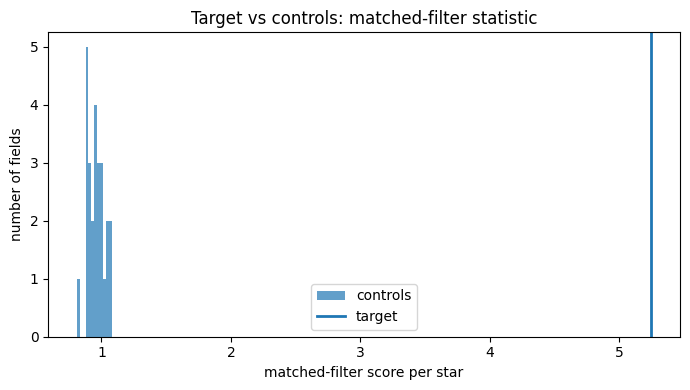

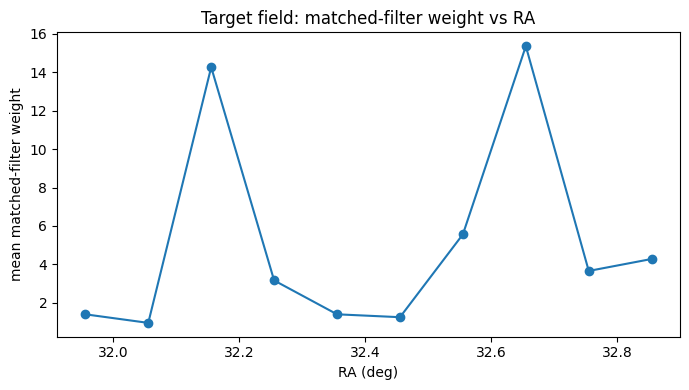

Linear trend: mean_w(RA) ≈ 3.478*RA + -107.6


In [ ]:
# -----------------------------
# 3) Weight lookup, log-ratio
# -----------------------------
W = np.log((S + EPS) / (B + EPS))

# helper: map each star (c,g) into a CMD bin and pull weight
def weights_for_df(df):
    if USE_MSTO_ONLY:
        df = df[in_msto_mask(df)].copy()

    c = df["g_r"].to_numpy()
    g = df["g0"].to_numpy()

    # digitize -> bin indices
    ic = np.digitize(c, c_edges) - 1
    ig = np.digitize(g, g_edges) - 1

    ok = (ic >= 0) & (ic < NBIN_C) & (ig >= 0) & (ig < NBIN_G)
    w = np.zeros(len(df), dtype=float)
    w[ok] = W[ic[ok], ig[ok]]
    return df, w

# compute a scalar matched-filter score per field: sum of weights
rows = []
for fid, df_field in fields:
    if len(df_field) == 0:
        continue
    sub, w = weights_for_df(df_field)
    score = np.sum(w)
    n = len(sub)
    rows.append({"field": fid, "N_used": n, "score": score, "score_per_star": score / max(n,1)})

mf = pd.DataFrame(rows).sort_values("field")
display(mf)

# detection statistic comparing target to controls
trow = mf[mf["field"] == "target"].iloc[0]
ctrl = mf[mf["field"] != "target"].copy()

mu = ctrl["score_per_star"].mean()
sig = ctrl["score_per_star"].std(ddof=1)
S_det = (trow["score_per_star"] - mu) / sig if sig > 0 else np.nan

print("=== Matched-filter detection (using score_per_star) ===")
print(f"Target: score/N = {trow['score_per_star']:.5g}  (N_used={int(trow['N_used'])})")
print(f"Controls: mean={mu:.5g}, std={sig:.5g} (n={len(ctrl)})")
print(f"Significance: {S_det:.2f} sigma")

# empirical p-value (one-sided: controls >= target)
p = (np.sum(ctrl["score_per_star"].to_numpy() >= trow["score_per_star"]) + 1) / (len(ctrl) + 1)
print(f"Empirical one-sided p-value: p = {p:.3f}")

plt.figure(figsize=(7,4))
plt.hist(ctrl["score_per_star"], bins=12, alpha=0.7, label="controls")
plt.axvline(trow["score_per_star"], linewidth=2, label="target")
plt.xlabel("matched-filter score per star")
plt.ylabel("number of fields")
plt.title("Target vs controls: matched-filter statistic")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 4) Target-only RA structure test using weights
# -----------------------------
sub_t, w_t = weights_for_df(df_target)

nbin = 10
bins = np.linspace(sub_t["ra"].min(), sub_t["ra"].max(), nbin+1)
centers = 0.5*(bins[:-1] + bins[1:])

mean_w = []
count = []
for lo, hi in zip(bins[:-1], bins[1:]):
    m = (sub_t["ra"] >= lo) & (sub_t["ra"] < hi)
    if np.any(m):
        mean_w.append(np.mean(w_t[m]))
        count.append(np.sum(m))
    else:
        mean_w.append(np.nan)
        count.append(0)

plt.figure(figsize=(7,4))
plt.plot(centers, mean_w, marker="o")
plt.xlabel("RA (deg)")
plt.ylabel("mean matched-filter weight")
plt.title("Target field: matched-filter weight vs RA")
plt.tight_layout()
plt.show()

# quick trend fit
x = centers[np.isfinite(mean_w)]
y = np.array(mean_w)[np.isfinite(mean_w)]
if len(x) >= 3:
    m, b = np.polyfit(x, y, 1)
    print(f"Linear trend: mean_w(RA) ≈ {m:.4g}*RA + {b:.4g}")
else:
    print("Not enough non-empty bins for a trend fit.")

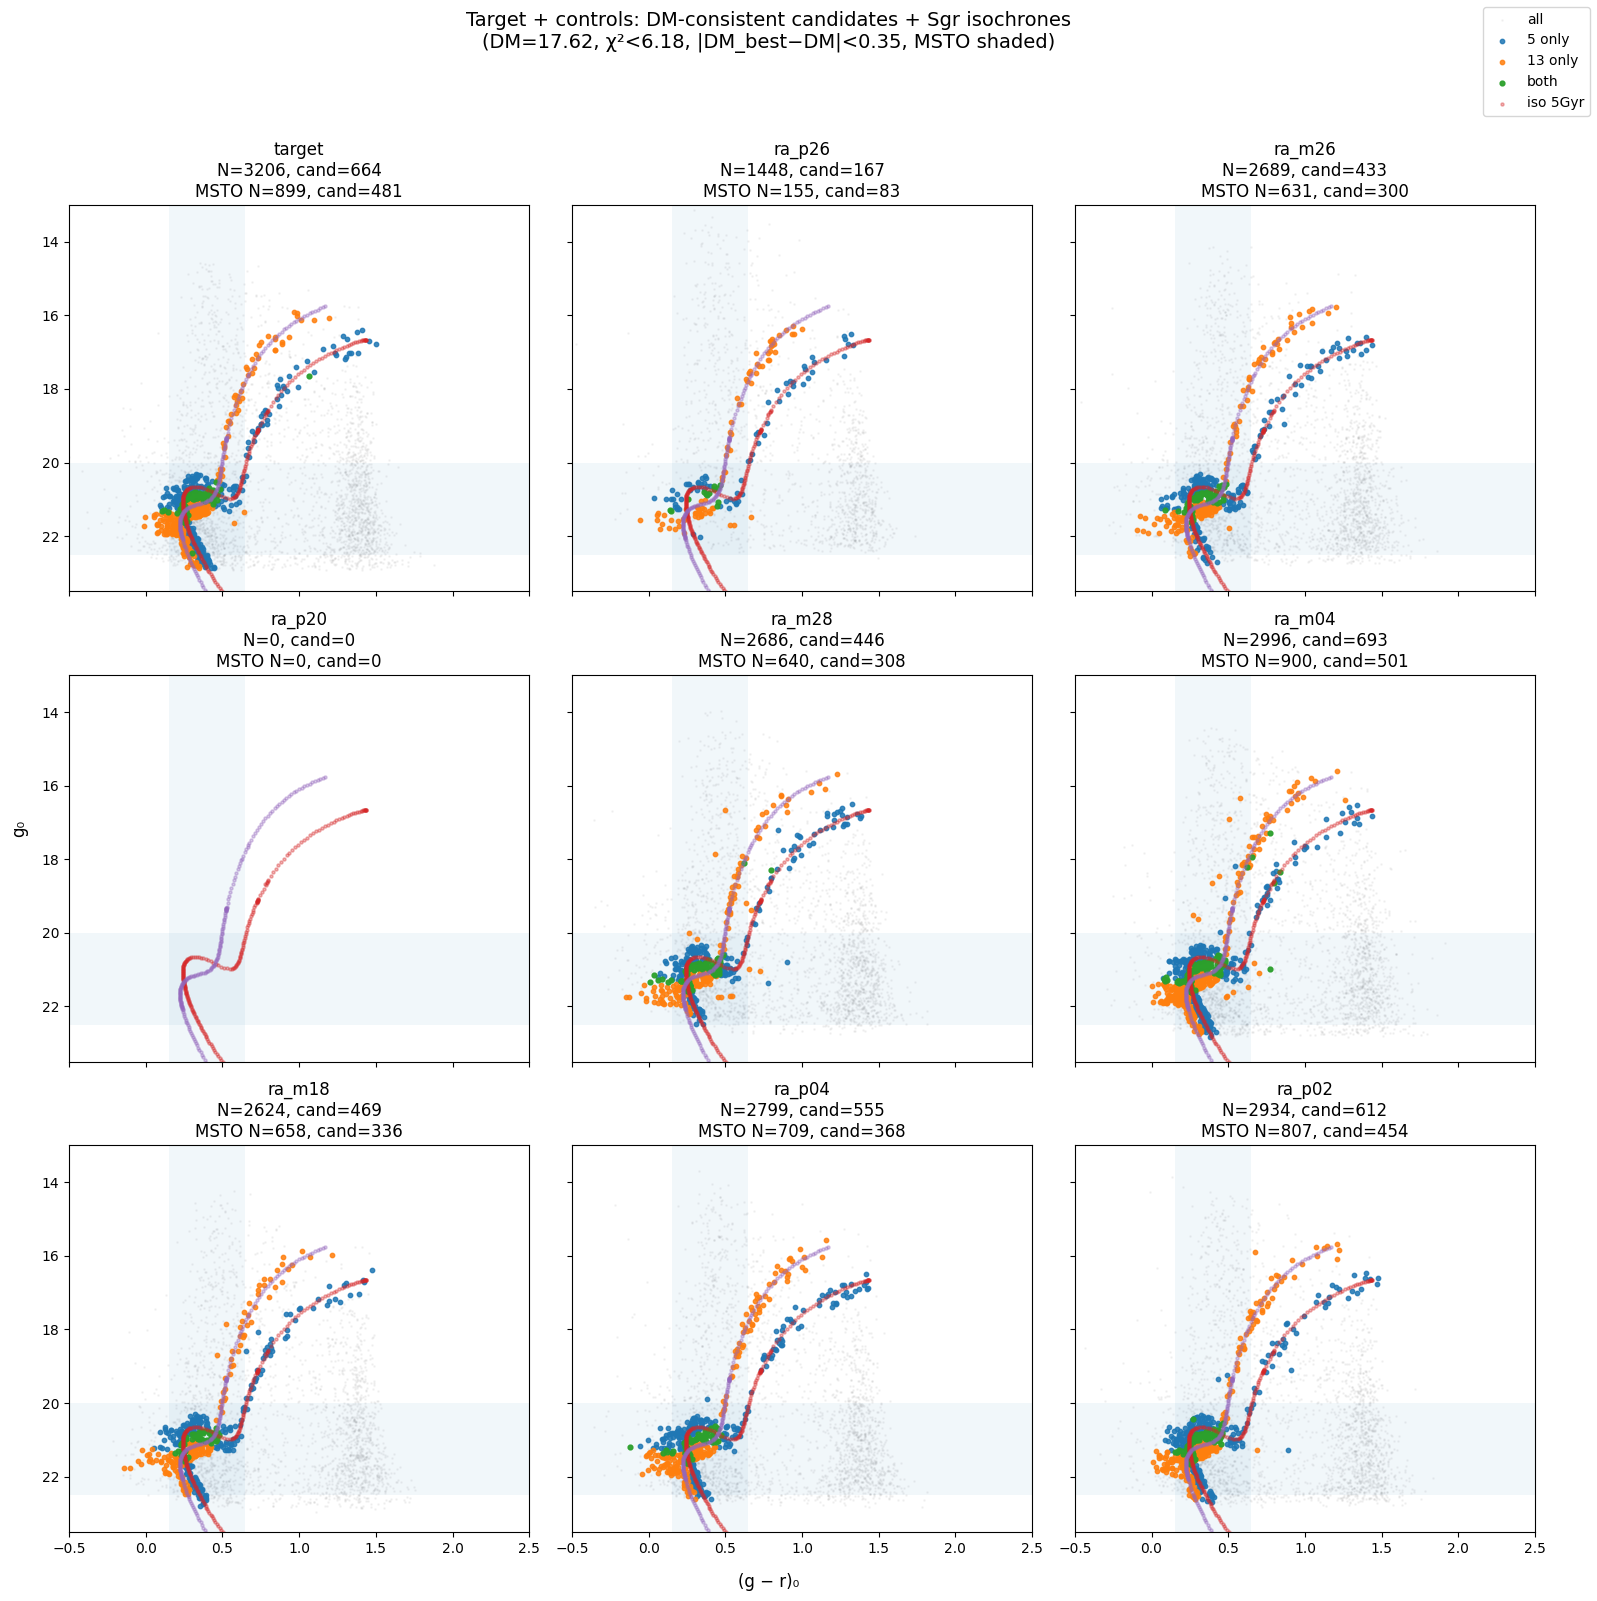

In [12]:
# --- pick fields to plot ---
field_map = {fid: df for fid, df in fields}
control_ids = [fid for fid in field_map.keys() if fid != "target"]
n_controls_to_plot = min(8, len(control_ids))
plot_ids = ["target"] + random.sample(control_ids, k=n_controls_to_plot)

# --- isochrones shifted to Sgr distance (for plotting only) ---
def iso_app_arrays(Mg_iso, Mr_iso, DM):
    g_app = Mg_iso + DM
    r_app = Mr_iso + DM
    c_app = g_app - r_app
    return c_app, g_app

c5_app, g5_app   = iso_app_arrays(Mg5,  Mr5,  DM_SGR)
c13_app, g13_app = iso_app_arrays(Mg13, Mr13, DM_SGR)

n = len(plot_ids)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 5.5*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, fid in zip(axes, plot_ids):
    dfp = field_map[fid]

    # background
    ax.scatter(dfp["g_r"], dfp["g0"], s=1, alpha=0.07, color="gray", label="all")

    # MSTO shading
    ax.axvspan(msto["cmin"], msto["cmax"], alpha=0.06)
    ax.axhspan(msto["gmin"], msto["gmax"], alpha=0.06)

    # candidates (correct logic)
    ax.scatter(dfp.loc[dfp["cand_5only"], "g_r"], dfp.loc[dfp["cand_5only"], "g0"],
               s=10, alpha=0.85, label="5 only")
    ax.scatter(dfp.loc[dfp["cand_13only"], "g_r"], dfp.loc[dfp["cand_13only"], "g0"],
               s=10, alpha=0.85, label="13 only")
    ax.scatter(dfp.loc[dfp["cand_both"], "g_r"], dfp.loc[dfp["cand_both"], "g0"],
               s=12, alpha=0.95, label="both")

    # isochrones as points
    ax.scatter(c5_app,  g5_app,  s=5, alpha=0.35, label="iso 5Gyr")
    ax.scatter(c13_app, g13_app, s=5, alpha=0.35, label="iso 13Gyr")

    N = len(dfp)
    Nc = int(dfp["cand_either"].sum())
    Nm = int(dfp["in_msto"].sum())
    Ncm = int(dfp["cand_msto"].sum())
    ax.set_title(f"{fid}\nN={N}, cand={Nc}\nMSTO N={Nm}, cand={Ncm}")

    ax.invert_yaxis()
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(23.5, 13)

for k in range(len(plot_ids), len(axes)):
    axes[k].axis("off")

fig.text(0.5, 0.04, "(g − r)₀", ha="center", fontsize=12)
fig.text(0.04, 0.5, "g₀", va="center", rotation="vertical", fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:5], labels[:5], loc="upper right", fontsize=10)

fig.suptitle(
    f"Target + controls: DM-consistent candidates + Sgr isochrones\n"
    f"(DM={DM_SGR:.2f}, χ²<{CHI2_THRESH}, |DM_best−DM|<{DM_TOL}, MSTO shaded)",
    y=0.995, fontsize=14
)

plt.tight_layout(rect=[0.05, 0.05, 0.98, 0.96])
plt.show()

,field,N_msto,N_cand_msto,f_cand_msto
1,ra_m02,855,478,0.559064
2,ra_m04,900,501,0.556667
3,ra_m06,976,525,0.537910
4,ra_m08,979,544,0.555669
5,ra_m10,924,463,0.501082
6,ra_m12,853,461,0.540445
7,ra_m14,813,411,0.505535
8,ra_m16,720,374,0.519444
9,ra_m18,658,336,0.510638
10,ra_m20,590,294,0.498305


=== Overdensity (MSTO only, DM-consistent candidates) ===
Target:    N=899, N_cand=481, f=0.53504
Controls:  mean f=0.50436, std f=0.04375  (n_used=26)
Excess:    Δf=0.03067
Significance: S = 0.70 σ
Empirical one-sided p-value (controls >= target): p = 0.296


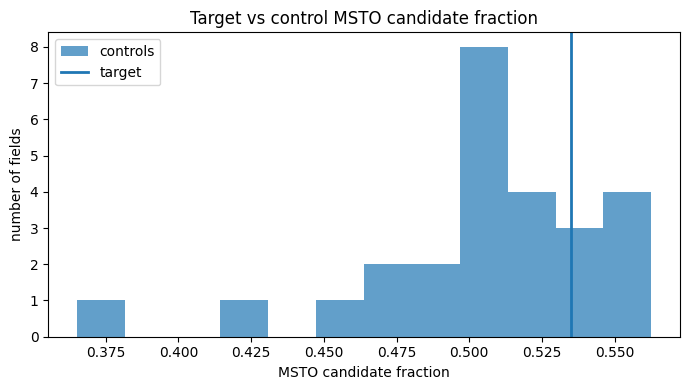

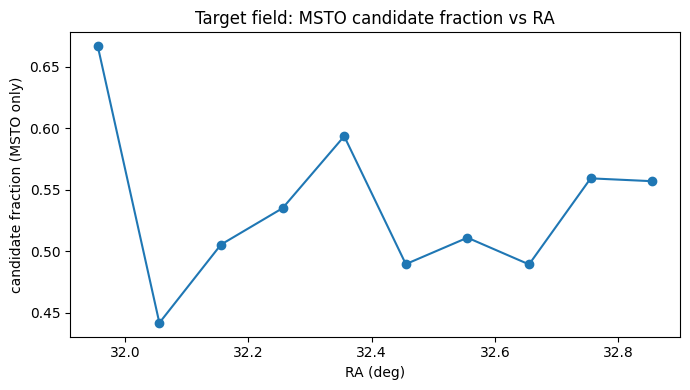

Linear trend: f(RA) ≈ -0.02563*RA + 1.365


In [13]:
# ---------- overdensity (MSTO only) ----------
rows = []
for fid, dfp in fields:
    N = int(dfp["in_msto"].sum())
    Nc = int(dfp["cand_msto"].sum())
    f = (Nc / N) if N > 0 else np.nan
    rows.append({"field": fid, "N_msto": N, "N_cand_msto": Nc, "f_cand_msto": f})

summary = pd.DataFrame(rows).sort_values("field")
display(summary)

target_row = summary[summary["field"] == "target"].iloc[0]
controls = summary[(summary["field"] != "target") & np.isfinite(summary["f_cand_msto"])].copy()

mu = controls["f_cand_msto"].mean()
sigma = controls["f_cand_msto"].std(ddof=1)
S = (target_row["f_cand_msto"] - mu) / sigma if sigma > 0 else np.nan

print("=== Overdensity (MSTO only, DM-consistent candidates) ===")
print(f"Target:    N={int(target_row['N_msto'])}, N_cand={int(target_row['N_cand_msto'])}, f={target_row['f_cand_msto']:.5f}")
print(f"Controls:  mean f={mu:.5f}, std f={sigma:.5f}  (n_used={len(controls)})")
print(f"Excess:    Δf={target_row['f_cand_msto']-mu:.5f}")
print(f"Significance: S = {S:.2f} σ")

ctrl_f = controls["f_cand_msto"].to_numpy()
p = (np.sum(ctrl_f >= target_row["f_cand_msto"]) + 1) / (len(ctrl_f) + 1)
print(f"Empirical one-sided p-value (controls >= target): p = {p:.3f}")

plt.figure(figsize=(7,4))
plt.hist(ctrl_f, bins=12, alpha=0.7, label="controls")
plt.axvline(target_row["f_cand_msto"], linewidth=2, label="target")
plt.xlabel("MSTO candidate fraction")
plt.ylabel("number of fields")
plt.title("Target vs control MSTO candidate fraction")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- spatial gradient test (target only; MSTO only) ----------
df_t = dict(fields)["target"].copy()
t = df_t[df_t["in_msto"]].copy()

nbin = 10
bins = np.linspace(t["ra"].min(), t["ra"].max(), nbin+1)
centers = 0.5*(bins[:-1] + bins[1:])

cand_frac = []
counts = []
for lo, hi in zip(bins[:-1], bins[1:]):
    s = t[(t["ra"] >= lo) & (t["ra"] < hi)]
    counts.append(len(s))
    cand_frac.append((s["cand_either"].sum() / len(s)) if len(s) > 0 else np.nan)

plt.figure(figsize=(7,4))
plt.plot(centers, cand_frac, marker="o")
plt.xlabel("RA (deg)")
plt.ylabel("candidate fraction (MSTO only)")
plt.title("Target field: MSTO candidate fraction vs RA")
plt.tight_layout()
plt.show()

x = centers[np.isfinite(cand_frac)]
y = np.array(cand_frac)[np.isfinite(cand_frac)]
if len(x) >= 3:
    m, b = np.polyfit(x, y, 1)
    print(f"Linear trend: f(RA) ≈ {m:.4g}*RA + {b:.4g}")
else:
    print("Not enough non-empty bins for a trend fit.")

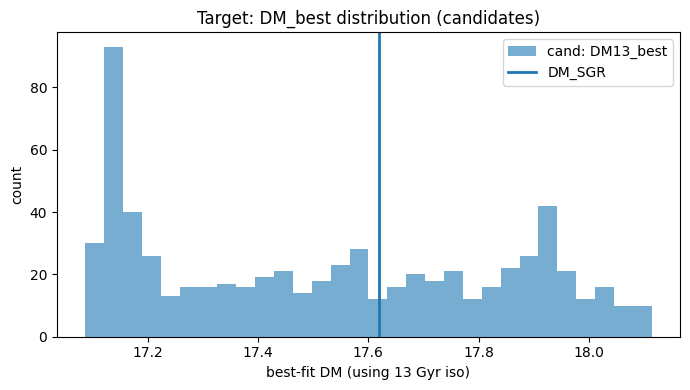

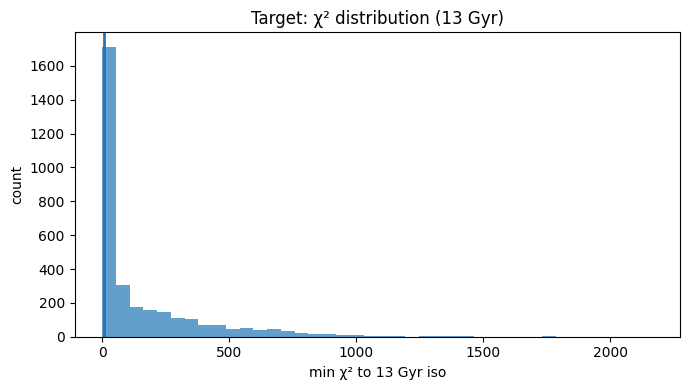

In [14]:
# ---------- diagnostics (target) ----------
df_t = dict(fields)["target"].copy()

plt.figure(figsize=(7,4))
plt.hist(df_t.loc[df_t["cand_either"], "DM13_best"].dropna(), bins=30, alpha=0.6, label="cand: DM13_best")
plt.axvline(DM_SGR, linewidth=2, label="DM_SGR")
plt.xlabel("best-fit DM (using 13 Gyr iso)")
plt.ylabel("count")
plt.title("Target: DM_best distribution (candidates)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.hist(df_t["chi2_13"][np.isfinite(df_t["chi2_13"])], bins=40, alpha=0.7)
plt.axvline(CHI2_THRESH, linewidth=2)
plt.xlabel("min χ² to 13 Gyr iso")
plt.ylabel("count")
plt.title("Target: χ² distribution (13 Gyr)")
plt.tight_layout()
plt.show()